Name: Sahil Suresh Ghogare

Roll no.: 23102A0061

Branch / Div: BE CMPN A

R_Experiment_5

**Installing required packages**

In [1]:
install.packages("igraph")
library(igraph)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




**Creating network using the recommended function**

In [2]:
data <- read.csv('/content/networkdata.csv', header=TRUE)
y <- data.frame(data$first, data$second)

net <- graph_from_data_frame(y, directed=TRUE)
V(net)$label <- V(net)$name
V(net)$degree <- degree(net)

**Histogram of node degree**

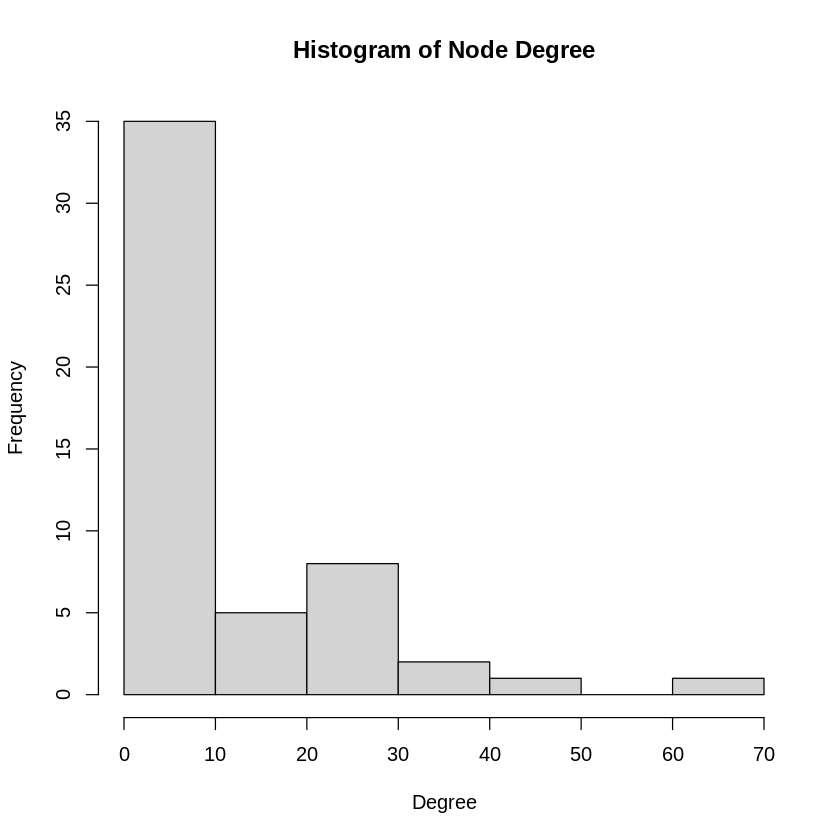

In [3]:
hist(V(net)$degree, main='Histogram of Node Degree', xlab='Degree')

**Network Diagram**

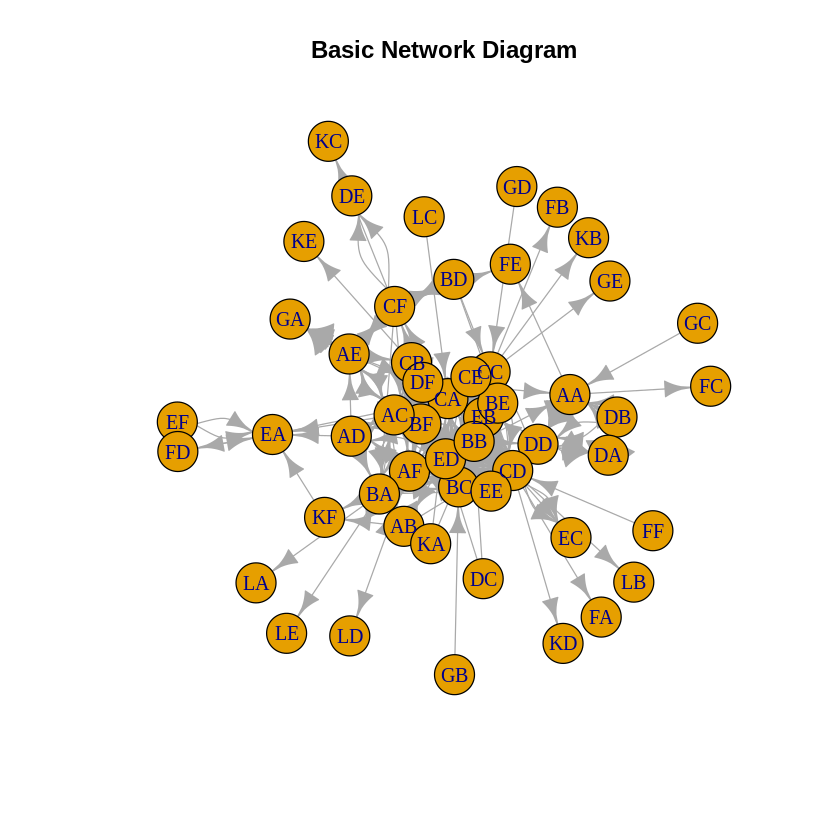

In [4]:
plot(net, main='Basic Network Diagram')

**Highlighting degrees & layouts**

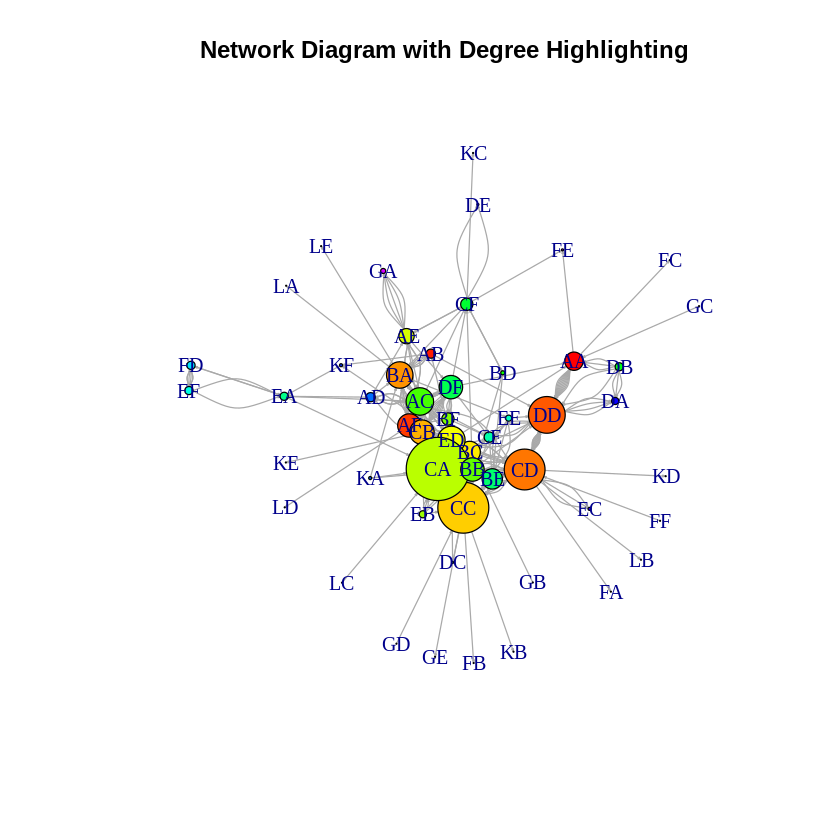

In [5]:
plot(net,
     vertex.color = rainbow(vcount(net)),
     vertex.size = V(net)$degree*0.4,
     edge.arrow.size = 0.1,
     layout=layout.fruchterman.reingold,
     main='Network Diagram with Degree Highlighting')

**Calculating and visualizing hub and authority scores for the network**

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority.score()` was deprecated in igraph 2.0.0.
ℹ Please use `hits_scores()` instead.”


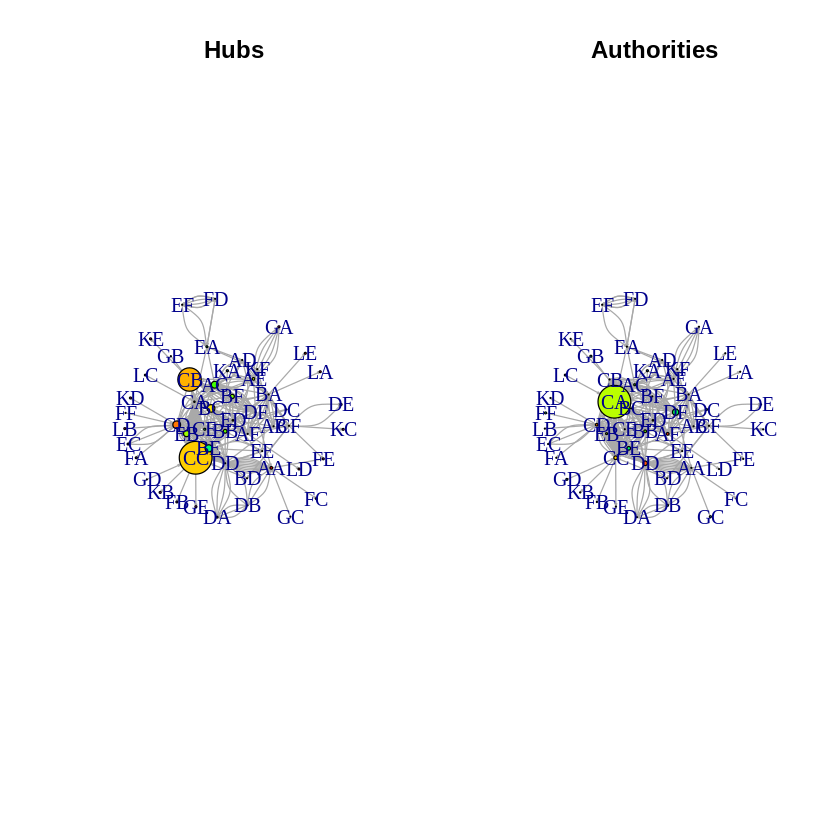

In [6]:
hs <- hub_score(net)$vector
as <- authority.score(net)$vector

par(mfrow=c(1,2))
set.seed(123)
plot(net,
     vertex.size=hs*30,
     main = 'Hubs',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size=0.1,
     layout = layout.kamada.kawai)

plot(net,
     vertex.size=as*30,
     main = 'Authorities',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size=0.1,
     layout = layout.kamada.kawai)
par(mfrow=c(1,1))

**community detection using the edge-betweenness algorithm on an undirected version of the network and visualize the detected communities.**

Warning message:
“`graph.data.frame()` was deprecated in igraph 2.0.0.
ℹ Please use `graph_from_data_frame()` instead.”


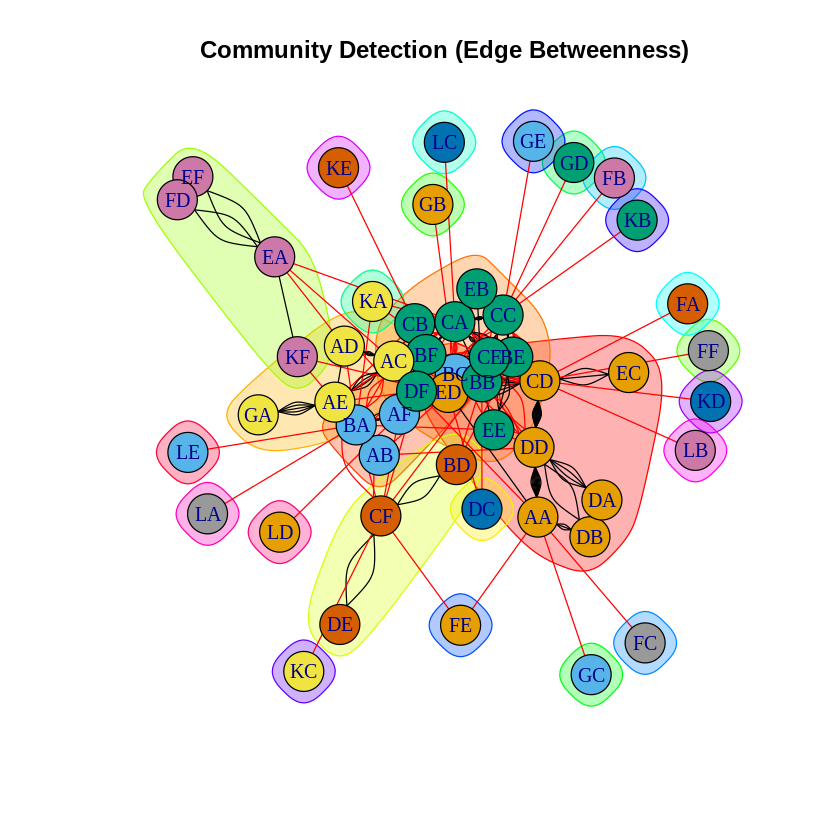

In [7]:
net_undirected <- graph.data.frame(y, directed = FALSE)
cnet <- cluster_edge_betweenness(net_undirected)
plot(cnet, net_undirected, main='Community Detection (Edge Betweenness)')